# Using Unlabeled Data with Self-Supervised Learning

## Pretraining with SimCLR

Also see
- https://github.com/sthalles/SimCLR

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import torchmetrics
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from torch.utils.tensorboard import SummaryWriter

torch.manual_seed(123)

In [2]:
base_transform = transforms.Compose([
    transforms.ToTensor(),
])

train_full   = torchvision.datasets.CIFAR10(root="data/", train=True,  download=True,  transform=base_transform)
test_dataset = torchvision.datasets.CIFAR10(root="data/", train=False, download=True,  transform=base_transform)

indices       = torch.randperm(len(train_full), generator=torch.Generator().manual_seed(123))
train_dataset = Subset(train_full, indices[:45000])
val_dataset   = Subset(train_full, indices[45000:])

tmp_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
images, labels = next(iter(tmp_loader))
print("Image shape:", images[0].shape)

100%|██████████| 170M/170M [00:02<00:00, 74.6MB/s] 


Image shape: torch.Size([3, 32, 32])


Image shape: torch.Size([3, 32, 32])


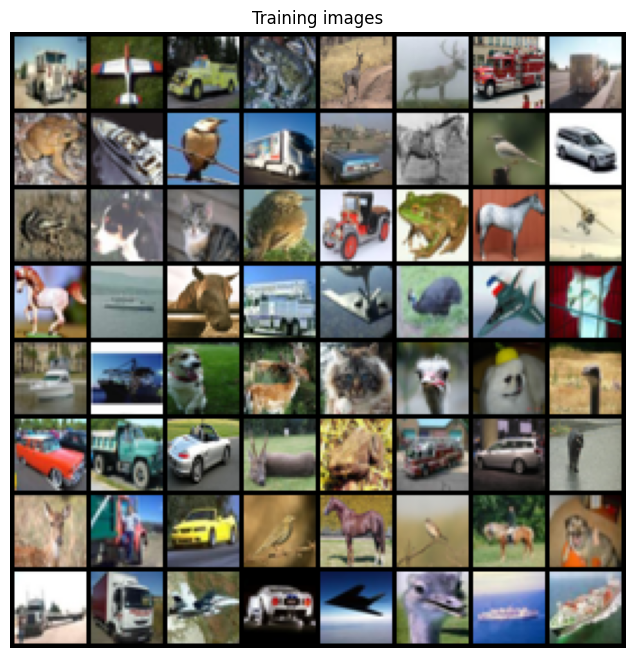

In [4]:
images, labels = next(iter(tmp_loader))
print("Image shape:", images[0].shape)

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Training images")
plt.imshow(np.transpose(
    torchvision.utils.make_grid(images[:64], padding=2, normalize=True).numpy(),
    (1, 2, 0)
))
plt.show()

In [5]:
images[0].shape

torch.Size([3, 32, 32])

## Image Sampler

Produces two augmented views per image

In [6]:
selfsupervised_transforms = transforms.Compose([
    transforms.RandomResizedCrop(size=128),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([transforms.ColorJitter(0.8, 0.8, 0.8, 0.2)], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.GaussianBlur(kernel_size=9, sigma=(0.1, 0.5)),
    transforms.ToTensor(),
])


class AugmentedImages:
    """Returns two independently augmented views of the same image."""
    def __init__(self, transforms):
        self.transforms = transforms

    def __call__(self, x):
        return [self.transforms(x), self.transforms(x)]

In [7]:
# Reload datasets with SimCLR augmentation
raw_train = torchvision.datasets.CIFAR10(root="data/", train=True,  download=False, transform=AugmentedImages(selfsupervised_transforms))
raw_test  = torchvision.datasets.CIFAR10(root="data/", train=False, download=False, transform=AugmentedImages(selfsupervised_transforms))

train_aug = Subset(raw_train, indices[:45000])
val_aug   = Subset(raw_train, indices[45000:])

train_loader = DataLoader(train_aug, batch_size=256, shuffle=True,  num_workers=4, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_aug,   batch_size=256, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(raw_test,  batch_size=256, shuffle=False, num_workers=4, pin_memory=True)

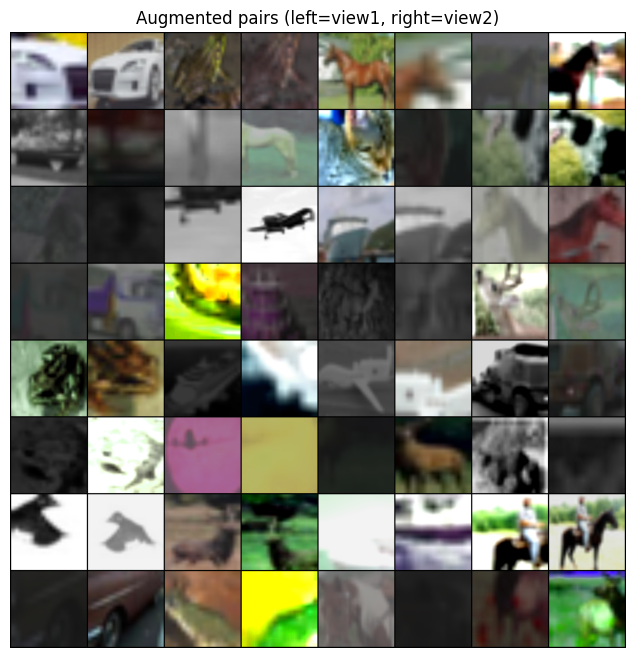

In [8]:
# Visualize paired augmentations
images, labels = next(iter(train_loader))

paired_images = []
for i in range(32):
    paired_images.append(images[0][i])
    paired_images.append(images[1][i])

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Augmented pairs (left=view1, right=view2)")
plt.imshow(np.transpose(
    torchvision.utils.make_grid(paired_images[:64], padding=2, normalize=True).numpy(),
    (1, 2, 0)
))
plt.show()

## Model — ResNet-18 with projection head 

(2 FC layers → embeddings, not classes)


In [9]:
pytorch_model = torch.hub.load('pytorch/vision', 'resnet18', weights=None)
pytorch_model.fc = nn.Sequential(
    nn.Linear(512, 512),
    nn.ReLU(),
    nn.Linear(512, 256),  # embedding space, not class logits
)

Using cache found in /home/zeus/.cache/torch/hub/pytorch_vision_main


## Info NCE Loss

Inspired by https://github.com/phlippe/uvadlc_notebooks/blob/master/docs/tutorial_notebooks/tutorial17/SimCLR.ipynb


In [10]:
def info_nce_loss(feats, temperature):
    # Cosine similarity between all pairs
    cos_sim = F.cosine_similarity(feats[:, None, :], feats[None, :, :], dim=-1)

    # Mask self-similarity
    self_mask = torch.eye(cos_sim.shape[0], dtype=torch.bool, device=cos_sim.device)
    cos_sim.masked_fill_(self_mask, -9e15)

    # Positive pair: batch_size//2 apart (view1 and view2 of same image)
    pos_mask = self_mask.roll(shifts=cos_sim.shape[0] // 2, dims=0)

    # InfoNCE
    cos_sim = cos_sim / temperature
    nll = -cos_sim[pos_mask] + torch.logsumexp(cos_sim, dim=-1)
    nll = nll.mean()

    # Ranking metric: position of positive pair in sorted similarities
    comb_sim = torch.cat(
        [cos_sim[pos_mask][:, None],
         cos_sim.masked_fill(pos_mask, -9e15)],
        dim=-1,
    )
    sim_argsort = comb_sim.argsort(dim=-1, descending=True).argmin(dim=-1)

    return nll, sim_argsort

## Training

In [11]:
def train_one_epoch(model, loader, optimizer, temperature, device):
    model.train()
    total_loss = 0.0
    top1_acc   = 0.0

    for (view1, view2), _ in loader:
        images = torch.cat([view1, view2], dim=0).to(device)
        optimizer.zero_grad()
        feats = model(images)
        loss, sim_argsort = info_nce_loss(feats, temperature)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * view1.size(0)
        top1_acc   += (sim_argsort == 0).float().mean().item() * view1.size(0)

    n = len(loader.dataset)
    return total_loss / n, top1_acc / n


def evaluate(model, loader, temperature, device):
    model.eval()
    total_loss = 0.0
    top1_acc   = 0.0

    with torch.inference_mode():
        for (view1, view2), _ in loader:
            images = torch.cat([view1, view2], dim=0).to(device)
            feats  = model(images)
            loss, sim_argsort = info_nce_loss(feats, temperature)

            total_loss += loss.item() * view1.size(0)
            top1_acc   += (sim_argsort == 0).float().mean().item() * view1.size(0)

    n = len(loader.dataset)
    return total_loss / n, top1_acc / n

In [12]:
#Setup
torch.manual_seed(123)
TEMPERATURE = 0.07
MAX_EPOCHS  = 50

device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = pytorch_model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
writer    = SummaryWriter(log_dir="logs/simclr-resnet18")

# Training

for epoch in range(1, MAX_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, TEMPERATURE, device)
    vl_loss, vl_acc = evaluate(model, val_loader, TEMPERATURE, device)

    writer.add_scalars("Loss",        {"train": tr_loss, "val": vl_loss}, epoch)
    writer.add_scalars("Top1-Acc",    {"train": tr_acc,  "val": vl_acc},  epoch)

    print(f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
          f"Train Loss: {tr_loss:.4f}  Top1: {tr_acc:.4f} | "
          f"Val Loss: {vl_loss:.4f}  Top1: {vl_acc:.4f}")

writer.close()

Epoch 01/50 | Train Loss: 5.8235  Top1: 0.0275 | Val Loss: 5.9066  Top1: 0.0312
Epoch 02/50 | Train Loss: 5.2366  Top1: 0.0826 | Val Loss: 4.9628  Top1: 0.1254
Epoch 03/50 | Train Loss: 4.5423  Top1: 0.1849 | Val Loss: 4.5134  Top1: 0.2087
Epoch 04/50 | Train Loss: 3.8691  Top1: 0.2961 | Val Loss: 3.8009  Top1: 0.3117
Epoch 05/50 | Train Loss: 3.3787  Top1: 0.3757 | Val Loss: 3.4355  Top1: 0.3840
Epoch 06/50 | Train Loss: 3.0121  Top1: 0.4409 | Val Loss: 3.1010  Top1: 0.4263
Epoch 07/50 | Train Loss: 2.7816  Top1: 0.4796 | Val Loss: 2.8460  Top1: 0.4758
Epoch 08/50 | Train Loss: 2.6067  Top1: 0.5094 | Val Loss: 2.8456  Top1: 0.4669
Epoch 09/50 | Train Loss: 2.4531  Top1: 0.5349 | Val Loss: 2.6467  Top1: 0.5095
Epoch 10/50 | Train Loss: 2.3544  Top1: 0.5519 | Val Loss: 2.3980  Top1: 0.5522
Epoch 11/50 | Train Loss: 2.2355  Top1: 0.5745 | Val Loss: 2.3094  Top1: 0.5746
Epoch 12/50 | Train Loss: 2.1207  Top1: 0.5940 | Val Loss: 2.2558  Top1: 0.5912
Epoch 13/50 | Train Loss: 2.0801  Top1: 

KeyboardInterrupt: 

In [13]:
torch.save(model.state_dict(), "simclr-resnet18.pt")
print("Saved simclr-resnet18.pt")

Saved simclr-resnet18.pt
